Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [2]:
df = pd.read_csv("credit_risk.csv")

Remove Duplicates

In [3]:
df = df.drop_duplicates()

Remove Completely Empty Rows

In [4]:
df = df.dropna(how="all")

Target Identification

In [5]:
target_col = [c for c in df.columns if df[c].nunique() == 2][-1]
print("Target column:", target_col)

Target column: Default


Target Distribution

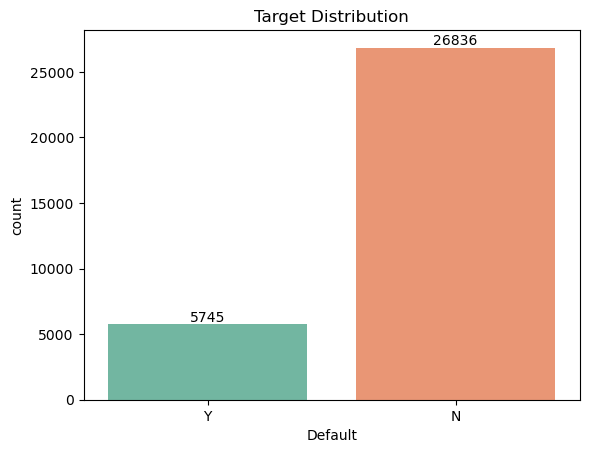

In [6]:
ax = sns.countplot(x=target_col, data=df, palette="Set2")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Target Distribution")
plt.show()

Numerical Feature Histograms

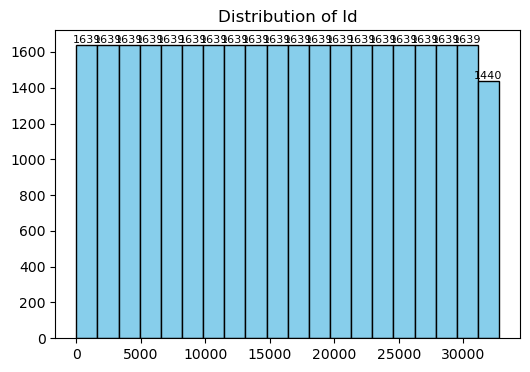

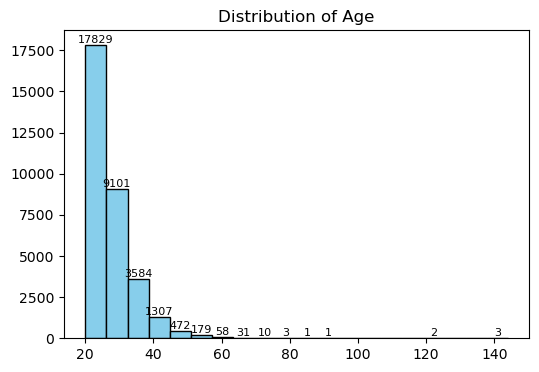

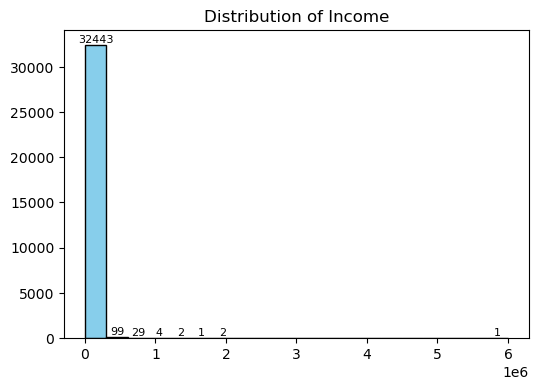

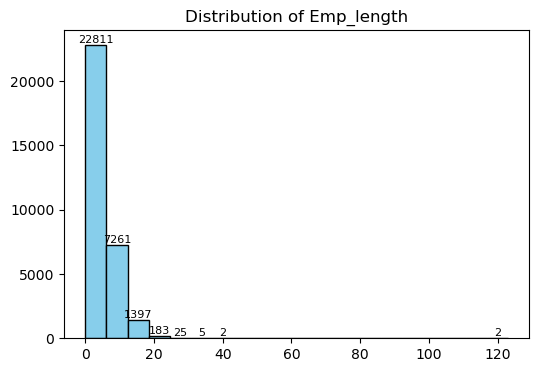

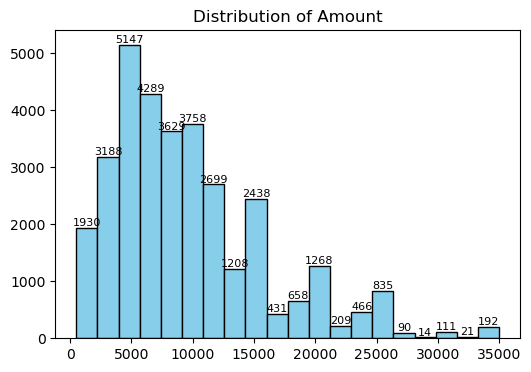

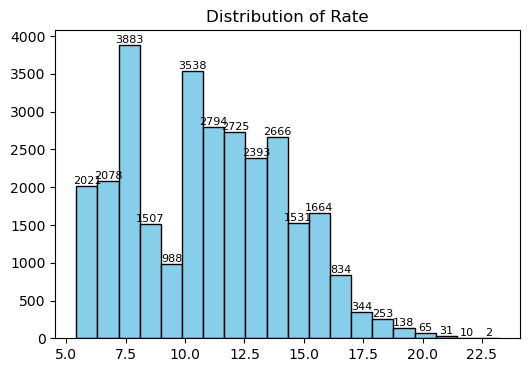

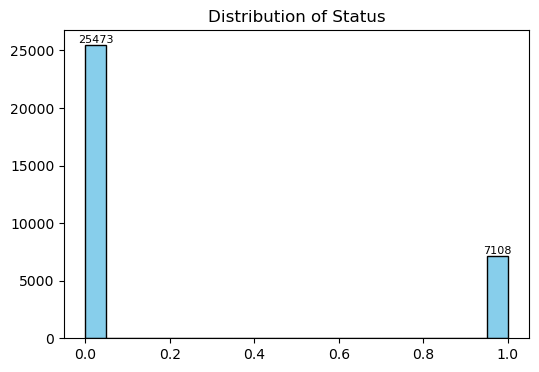

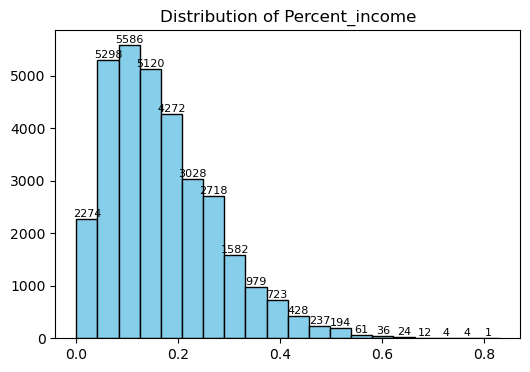

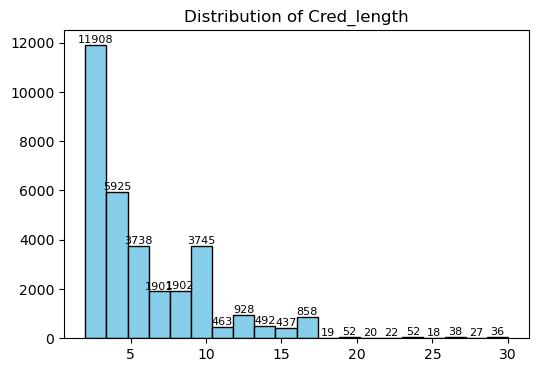

In [7]:
num_data = df.select_dtypes(include=["int64", "float64"])

for col in num_data.columns:
    plt.figure(figsize=(6,4))
    counts, bins, patches = plt.hist(
        num_data[col].dropna(),
        bins=20,
        color="skyblue",
        edgecolor="black"
    )
    for count, patch in zip(counts, patches):
        if count > 0:
            plt.text(
                patch.get_x() + patch.get_width()/2,
                count,
                int(count),
                ha="center",
                va="bottom",
                fontsize=8
            )
    plt.title(f"Distribution of {col}")
    plt.show()

Boxplots

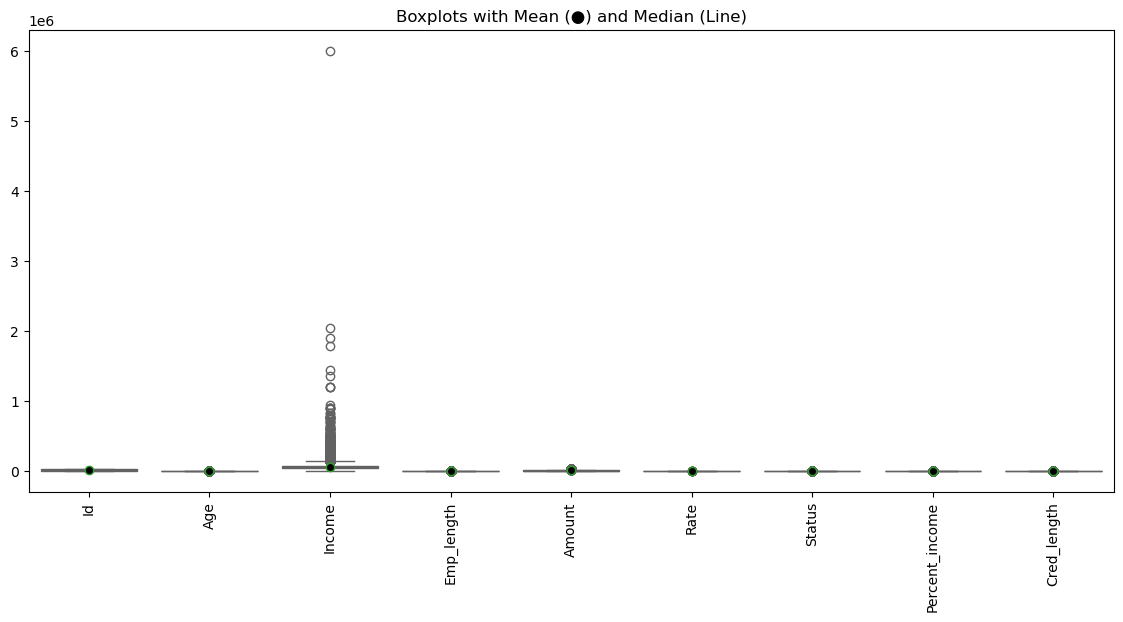

In [8]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=num_data,
    palette="Set3",
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"black","markersize":6}
)
plt.xticks(rotation=90)
plt.title("Boxplots with Mean (●) and Median (Line)")
plt.show()

Correlation Heatmap

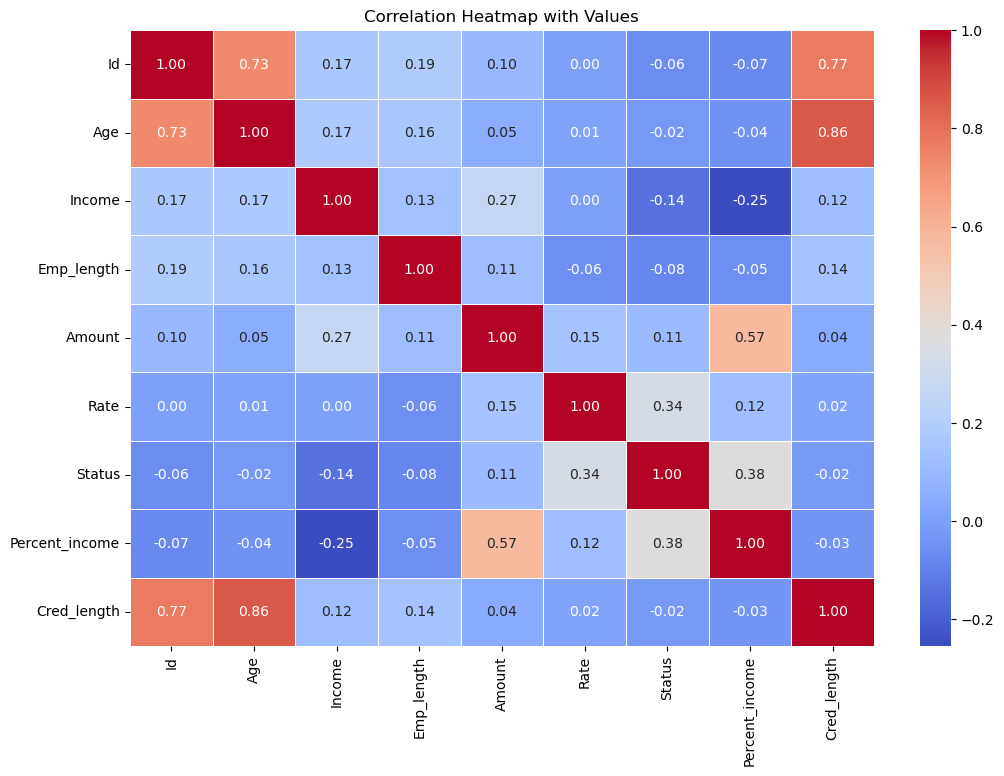

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(
    num_data.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap with Values")
plt.show()

Annotated Scatter Plots

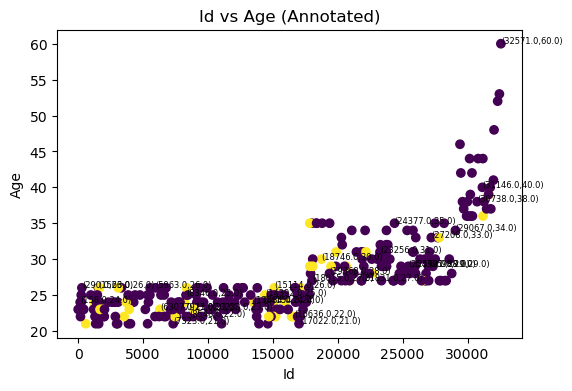

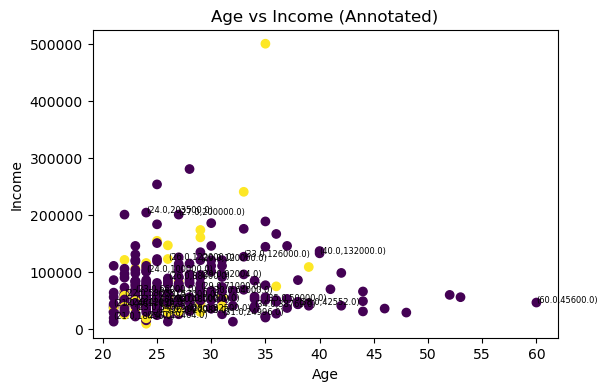

In [10]:
sample_df = df.sample(min(300, len(df)))

num_cols_sample = num_data.columns[:3]

for i in range(len(num_cols_sample)-1):
    plt.figure(figsize=(6,4))
    x = sample_df[num_cols_sample[i]]
    y = sample_df[num_cols_sample[i+1]]

    # Map 'Y'/'N' to 1/0 for coloring
    color_vals = sample_df[target_col].map({'Y': 1, 'N': 0})
    plt.scatter(x, y, c=color_vals, cmap="viridis")

    for xi, yi in zip(x.head(30), y.head(30)):
        plt.text(xi, yi, f"({xi:.1f},{yi:.1f})", fontsize=6)

    plt.xlabel(num_cols_sample[i])
    plt.ylabel(num_cols_sample[i+1])
    plt.title(f"{num_cols_sample[i]} vs {num_cols_sample[i+1]} (Annotated)")
    plt.show()

Missing Values Bar Plot

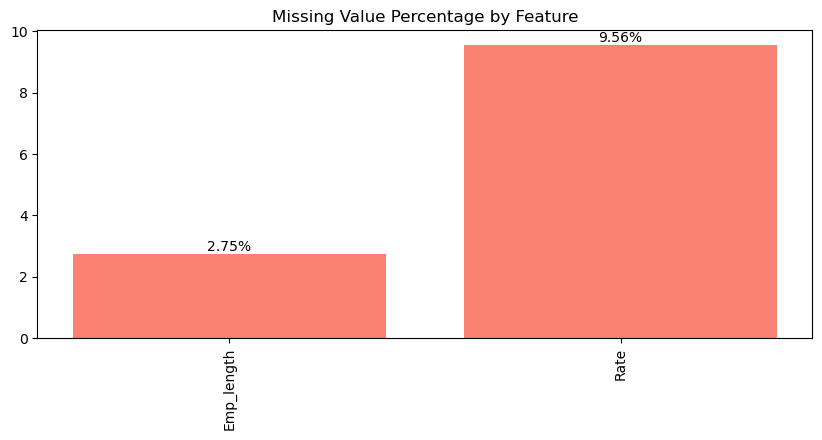

In [11]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10,4))
bars = plt.bar(missing_pct.index, missing_pct.values, color="salmon")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=90)
plt.title("Missing Value Percentage by Feature")
plt.show()

Missing Value Overview

In [12]:
(df.isna().sum() / len(df)).sort_values(ascending=False).head(10)

Rate              0.095639
Emp_length        0.027470
Id                0.000000
Age               0.000000
Home              0.000000
Income            0.000000
Intent            0.000000
Amount            0.000000
Status            0.000000
Percent_income    0.000000
dtype: float64

Feature / Target Split

In [13]:
X = df.drop(columns=[target_col])
y = df[target_col]

Column Types

In [14]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

Train–Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Preprocessing WITH IMPUTERS

In [16]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

Logistic Regression

In [17]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

Random Forest

In [18]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

XGBoost

In [19]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train_enc)

xgb_pred = le.inverse_transform(xgb_model.predict(X_test))
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

MODEL COMPARISON TABLE

In [20]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred, pos_label='Y'),
        precision_score(y_test, rf_pred, pos_label='Y'),
        precision_score(y_test, xgb_pred, pos_label='Y')
    ],
    "Recall": [
        recall_score(y_test, log_pred, pos_label='Y'),
        recall_score(y_test, rf_pred, pos_label='Y'),
        recall_score(y_test, xgb_pred, pos_label='Y')
    ],
    "F1": [
        f1_score(y_test, log_pred, pos_label='Y'),
        f1_score(y_test, rf_pred, pos_label='Y'),
        f1_score(y_test, xgb_pred, pos_label='Y')
    ],
    "AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.826914,0.517185,0.275022,0.359091,0.870229
1,Random Forest,0.825380,0.511530,0.212359,0.300123,0.883306
2,XGBoost,0.827681,0.512922,0.449086,0.478886,0.887977


ROC CURVES

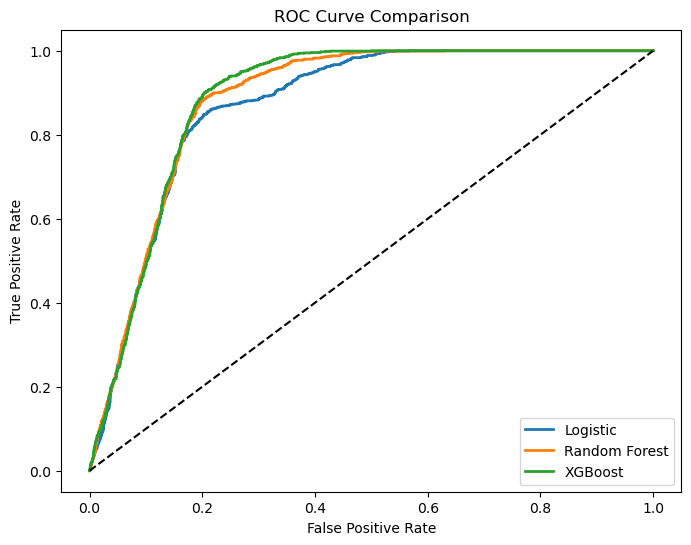

In [21]:
plt.figure(figsize=(8,6))

plt.plot(*roc_curve(y_test, log_prob, pos_label='Y')[:2], label="Logistic", linewidth=2)
plt.plot(*roc_curve(y_test, rf_prob, pos_label='Y')[:2], label="Random Forest", linewidth=2)
plt.plot(*roc_curve(y_test, xgb_prob, pos_label='Y')[:2], label="XGBoost", linewidth=2)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()